# Continuous distributions: an introduction with real-looking hospital data

**Master in Healthcare Analytics · Session: Continuous distributions**
Dataset: Outpatient appointments, Riverbend Community Hospital (fictional), calendar year 2025.

In this notebook we look at three variables from the outpatient scheduling system and ask one simple question about each: **what does its distribution look like?** We will describe each one with a histogram, a handful of summary numbers, and a "shape" word (symmetric, skewed, bumpy). Along the way we meet two classic continuous distributions, the **normal** and the **log-normal**, and one situation where no single distribution fits because the data is really a mix of groups.

No formulas are needed today. The goal is to build intuition for how to look at a continuous variable before doing anything else with it. Later sessions will go deeper into exploratory data analysis and modelling.

## 1. The data

Two files from the hospital's scheduling system:

- `appointments.csv` — one row per scheduled appointment (79,253 rows). Who was booked, with whom, when, how far in advance, and whether the patient showed up.
- `patients.csv` — one row per patient (11,523 rows). Age, sex, insurance, and how far the patient lives from the clinic.

Everything is synthetic (no real people), but the sizes and shapes are realistic for a US community hospital.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Plot styling (kept simple and consistent across the notebook)
BLUE, ORANGE, AQUA, INK, MUTED, GRID = "#2a78d6", "#eb6834", "#1baf7a", "#0b0b0b", "#898781", "#e1e0d9"
plt.rcParams.update({"figure.figsize": (8, 4), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
                     "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
                     "font.family": "sans-serif", "font.size": 10})

appointments = pd.read_csv("https://raw.githubusercontent.com/thousandoaks/Maths4DS-I/refs/heads/main/data/appointments.csv", parse_dates=["booking_date", "appointment_date"])
patients = pd.read_csv("https://raw.githubusercontent.com/thousandoaks/Maths4DS-I/refs/heads/main/data/patients.csv")
print(appointments.shape, patients.shape)





(79253, 18) (11523, 7)


In [7]:
appointments.head()

,appointment_id,patient_id,provider_id,clinic,visit_type,booking_date,appointment_date,appointment_time,weekday,slot_period,lead_time_days,prior_no_shows,sex,age,primary_payer,residence_type,distance_miles,status
0,A000001,P000240,DR023,Orthopedics,Established,2024-12-30,2025-01-02,08:00,Thursday,Early morning,3,4,M,46,Commercial,Suburban,9.6,Cancelled by clinic
1,A000002,P000663,DR023,Orthopedics,Annual wellness,2024-12-11,2025-01-02,08:00,Thursday,Early morning,22,0,F,40,Commercial,Urban,1.2,Arrived
2,A000003,P001386,DR024,Orthopedics,Telehealth,2024-12-20,2025-01-02,08:00,Thursday,Early morning,13,0,F,42,Commercial,Rural,6.5,Arrived
3,A000004,P001895,DR021,Orthopedics,Established,2024-12-28,2025-01-02,08:00,Thursday,Early morning,5,1,M,56,Commercial,Urban,1.8,Arrived
4,A000005,P002435,DR007,Family Medicine,New patient,2024-12-25,2025-01-02,08:00,Thursday,Early morning,8,0,M,53,Commercial,Rural,17.4,Cancelled by patient


In [8]:
patients.head()

,patient_id,sex,age,primary_payer,residence_type,distance_miles,home_clinic
0,P000001,M,18,Commercial,Suburban,9.2,Family Medicine
1,P000002,M,52,Commercial,Urban,5.2,Cardiology
2,P000003,M,42,Medicaid,Urban,4.0,Internal Medicine
3,P000004,F,32,Medicaid,Urban,2.3,Family Medicine
4,P000005,F,18,Medicaid,Urban,3.9,Internal Medicine


### Which table to use for which variable?

`age` and `distance_miles` describe the **patient**, and are simply copied onto every appointment row. If we drew a histogram of age from `appointments.csv`, patients with many appointments would be counted many times. So for those two variables we use `patients.csv`.

`lead_time_days` (days between booking and appointment) describes the **appointment**, so it comes from `appointments.csv`.

## 2. What is a continuous variable?

A variable is *continuous* when it can take any value in a range: age, distance, waiting time, blood pressure, cost. In practice it is often recorded in whole units (age in years, lead time in days) but we still treat it as continuous because there are many possible values and the gaps between them do not matter.

For a continuous variable we usually want to know four things:

1. **Where is the centre?** — mean and median.
2. **How spread out is it?** — standard deviation, quartiles, minimum and maximum.
3. **What shape does it have?** — symmetric, right-skewed (long tail to the right), left-skewed, or several bumps.
4. **Does a known distribution describe it?** — for example the normal (bell curve) or the log-normal.

A small helper to print the summary numbers we care about:

In [9]:
def describe(x, name):
    q = x.quantile([0.25, 0.5, 0.75, 0.9])
    print(f"{name}")
    print(f"  n = {len(x):,}")
    print(f"  mean = {x.mean():.1f}   median = {q[0.5]:.1f}   std = {x.std():.1f}")
    print(f"  min = {x.min():.1f}   Q1 = {q[0.25]:.1f}   Q3 = {q[0.75]:.1f}   P90 = {q[0.9]:.1f}   max = {x.max():.1f}")
    print(f"  skewness = {stats.skew(x):.2f}   (0 = symmetric, > 0 = tail to the right)")

## 3. Age — a roughly symmetric variable

Patient age at the start of the year, adults only.

In [10]:
age = patients["age"]
describe(age, "Age (years), one value per patient")

Age (years), one value per patient
  n = 11,523
  mean = 52.3   median = 52.0   std = 17.4
  min = 18.0   Q1 = 40.0   Q3 = 65.0   P90 = 75.0   max = 95.0
  skewness = 0.07   (0 = symmetric, > 0 = tail to the right)


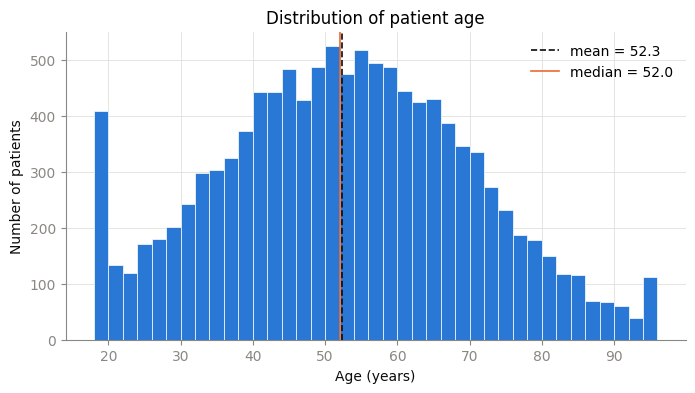

In [11]:
fig, ax = plt.subplots()
ax.hist(age, bins=range(18, 97, 2), color=BLUE, edgecolor="white", linewidth=0.5)
ax.axvline(age.mean(), color=INK, linestyle="--", linewidth=1.2, label=f"mean = {age.mean():.1f}")
ax.axvline(age.median(), color=ORANGE, linestyle="-", linewidth=1.2, label=f"median = {age.median():.1f}")
ax.set_xlabel("Age (years)"); ax.set_ylabel("Number of patients"); ax.set_title("Distribution of patient age")
ax.legend(frameon=False); plt.show()

**What we see.** The mean and median almost coincide (52.3 vs 52.0) and the skewness is close to zero: the distribution is **symmetric**, with most patients between about 35 and 70. This is the kind of shape the **normal distribution** (the bell curve) describes. A normal distribution is fully specified by two numbers, its mean and its standard deviation, so let us draw the normal curve with the same mean and standard deviation as our data on top of the histogram.

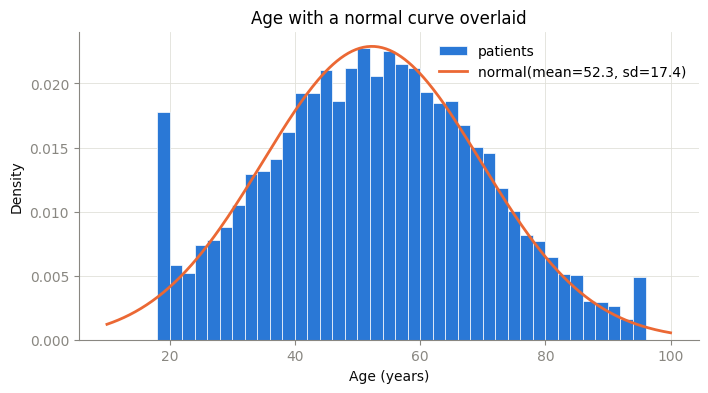

In [12]:
mu, sigma = age.mean(), age.std()
xs = np.linspace(10, 100, 300)
fig, ax = plt.subplots()
ax.hist(age, bins=range(18, 97, 2), density=True, color=BLUE, edgecolor="white", linewidth=0.5, label="patients")
ax.plot(xs, stats.norm.pdf(xs, mu, sigma), color=ORANGE, linewidth=2, label=f"normal(mean={mu:.1f}, sd={sigma:.1f})")
ax.set_xlabel("Age (years)"); ax.set_ylabel("Density"); ax.set_title("Age with a normal curve overlaid")
ax.legend(frameon=False); plt.show()

The curve follows the histogram well through the middle. It is not perfect at the edges: the hospital only sees adults, so there is nobody under 18 and a small pile-up exactly at 18, and nobody over 95. Real variables are never *exactly* normal; what matters is whether the normal curve is a useful description for the question at hand.

One practical use: if the normal curve is a good description, we can answer questions like "what share of patients are 65 or older?" from the curve alone, and check it against the data.

In [13]:
share_data = (age >= 65).mean()
share_normal = 1 - stats.norm.cdf(65, mu, sigma)
print(f"Share of patients aged 65+  —  from the data: {share_data:.1%}   from the normal curve: {share_normal:.1%}")

Share of patients aged 65+  —  from the data: 25.1%   from the normal curve: 23.3%


## 4. Lead time — a right-skewed variable

Lead time is the number of days between the day an appointment was booked and the appointment itself. This is an operational variable: long lead times mean long waits for care.

In [14]:
lead = appointments["lead_time_days"]
describe(lead, "Lead time (days), one value per appointment")

Lead time (days), one value per appointment
  n = 79,253
  mean = 15.7   median = 11.0   std = 15.8
  min = 0.0   Q1 = 6.0   Q3 = 19.0   P90 = 33.0   max = 120.0
  skewness = 2.82   (0 = symmetric, > 0 = tail to the right)


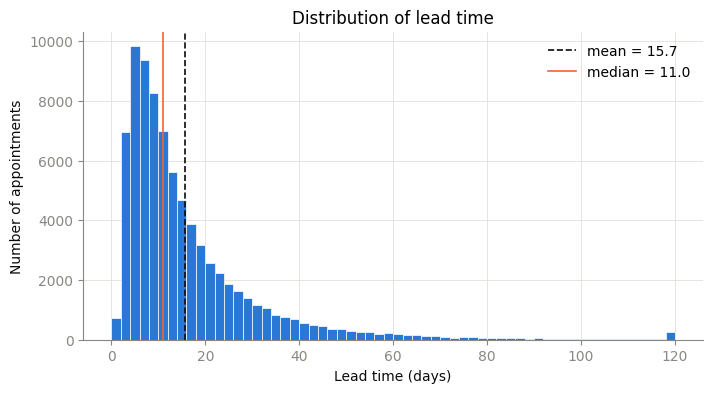

In [15]:
fig, ax = plt.subplots()
ax.hist(lead, bins=range(0, 122, 2), color=BLUE, edgecolor="white", linewidth=0.5)
ax.axvline(lead.mean(), color=INK, linestyle="--", linewidth=1.2, label=f"mean = {lead.mean():.1f}")
ax.axvline(lead.median(), color=ORANGE, linestyle="-", linewidth=1.2, label=f"median = {lead.median():.1f}")
ax.set_xlabel("Lead time (days)"); ax.set_ylabel("Number of appointments"); ax.set_title("Distribution of lead time")
ax.legend(frameon=False); plt.show()

**What we see.** This looks nothing like a bell. Most appointments are booked within two weeks, but a long tail stretches out to 120 days. The distribution is **right-skewed** (skewness 2.8): the mean (15.7 days) is pulled to the right of the median (11 days) by the tail.

Two lessons for reporting:

- For skewed variables, **report the median**, not the mean. "Half of appointments are booked 11 days or less in advance" is a fair summary; "the average lead time is 16 days" is misleading because few appointments are actually near 16.
- **High percentiles describe the tail.** The 90th percentile (P90 above) tells us the wait that one appointment in ten exceeds; that is what patients complain about.

Many right-skewed quantities in healthcare (waiting times, length of stay, costs) become symmetric if we take their **logarithm**. Let us try that with lead time (leaving out the few appointments booked the same day, whose lead time is zero, because the logarithm of zero is not defined).

Skewness of lead time: 2.82   Skewness of log(lead time): -0.02


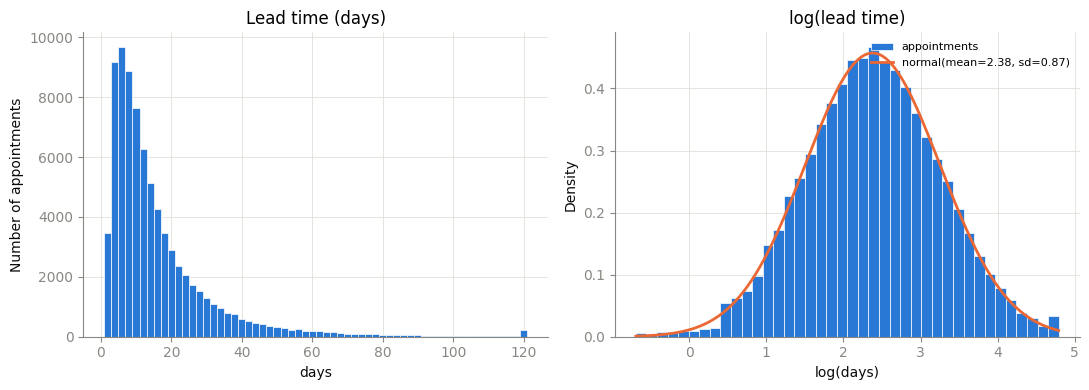

In [16]:
lead_pos = lead[lead > 0]
# Lead time is recorded in whole days. Adding a small random amount between -0.5 and +0.5
# ("jitter") smooths the whole-day rounding so the histogram of the logarithm is not gappy.
rng = np.random.default_rng(1)
log_lead = np.log(lead_pos + rng.uniform(-0.5, 0.5, len(lead_pos)))
print(f"Skewness of lead time: {stats.skew(lead_pos):.2f}   Skewness of log(lead time): {stats.skew(log_lead):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(lead_pos, bins=range(1, 122, 2), color=BLUE, edgecolor="white", linewidth=0.5)
axes[0].set_title("Lead time (days)"); axes[0].set_xlabel("days"); axes[0].set_ylabel("Number of appointments")
axes[1].hist(log_lead, bins=40, density=True, color=BLUE, edgecolor="white", linewidth=0.5, label="appointments")
m, s = log_lead.mean(), log_lead.std()
xs = np.linspace(log_lead.min(), log_lead.max(), 300)
axes[1].plot(xs, stats.norm.pdf(xs, m, s), color=ORANGE, linewidth=2, label=f"normal(mean={m:.2f}, sd={s:.2f})")
axes[1].set_title("log(lead time)"); axes[1].set_xlabel("log(days)"); axes[1].set_ylabel("Density"); axes[1].legend(frameon=False, loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

After taking logs, the histogram is symmetric and a normal curve fits it well. A variable whose logarithm is normal is said to follow a **log-normal distribution**. That is the single most useful distribution for skewed, strictly positive healthcare quantities.

A practical consequence: when a variable is log-normal, its **median** is the natural "typical value" (it equals the exponential of the mean of the logs), while its mean is always higher.

In [17]:
print(f"exp(mean of log lead time) = {np.exp(m):.1f} days   median of lead time = {lead_pos.median():.1f} days   mean of lead time = {lead_pos.mean():.1f} days")

exp(mean of log lead time) = 10.8 days   median of lead time = 11.0 days   mean of lead time = 15.7 days


Finally, a distribution can hide differences between groups. Lead times differ a lot between clinics, because specialty clinics have longer waiting lists.

                   median  mean   P90
clinic                               
Family Medicine       7.0   9.0  18.0
Internal Medicine    10.0  13.7  27.0
Orthopedics          17.0  21.5  41.0
Cardiology           24.0  30.7  61.0


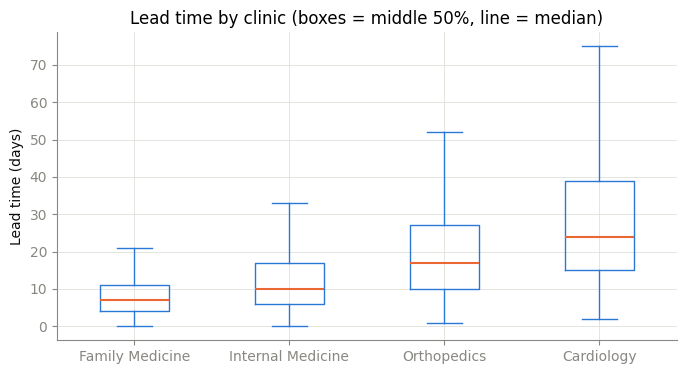

In [18]:
order = ["Family Medicine", "Internal Medicine", "Orthopedics", "Cardiology"]
by_clinic = appointments.groupby("clinic")["lead_time_days"].agg(["median", "mean", lambda x: x.quantile(0.9)])
by_clinic.columns = ["median", "mean", "P90"]
print(by_clinic.loc[order].round(1))

fig, ax = plt.subplots()
ax.boxplot([appointments.loc[appointments.clinic == c, "lead_time_days"] for c in order],
           tick_labels=order, showfliers=False, medianprops=dict(color=ORANGE, linewidth=1.5),
           boxprops=dict(color=BLUE), whiskerprops=dict(color=BLUE), capprops=dict(color=BLUE))
ax.set_ylabel("Lead time (days)"); ax.set_title("Lead time by clinic (boxes = middle 50%, line = median)")
plt.show()

## 5. Distance to the clinic — a mixture of groups

How far each patient lives from the clinic, in miles (straight line).

In [19]:
dist = patients["distance_miles"]
describe(dist, "Distance to clinic (miles), one value per patient")

Distance to clinic (miles), one value per patient
  n = 11,523
  mean = 9.1   median = 5.7   std = 9.4
  min = 0.5   Q1 = 3.2   Q3 = 11.2   P90 = 20.6   max = 80.0
  skewness = 2.64   (0 = symmetric, > 0 = tail to the right)


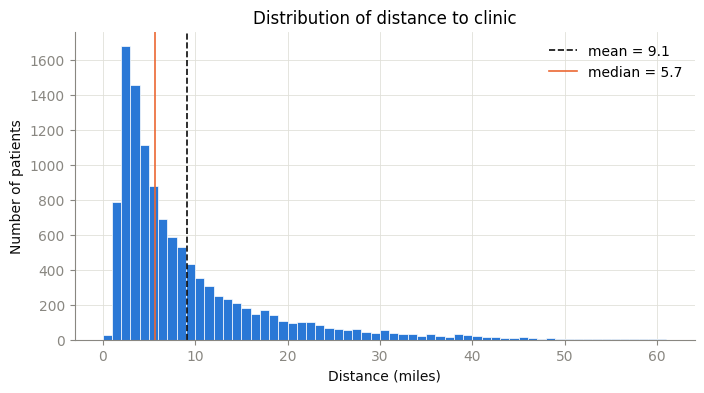

In [20]:
fig, ax = plt.subplots()
ax.hist(dist, bins=np.arange(0, 62, 1), color=BLUE, edgecolor="white", linewidth=0.5)
ax.axvline(dist.mean(), color=INK, linestyle="--", linewidth=1.2, label=f"mean = {dist.mean():.1f}")
ax.axvline(dist.median(), color=ORANGE, linestyle="-", linewidth=1.2, label=f"median = {dist.median():.1f}")
ax.set_xlabel("Distance (miles)"); ax.set_ylabel("Number of patients"); ax.set_title("Distribution of distance to clinic")
ax.legend(frameon=False); plt.show()

**What we see.** Again right-skewed, with the mean (9.1 miles) well above the median (5.7). So far it looks like lead time. But the tail is different: instead of thinning out smoothly like lead time does, it stays thick and almost flat from about 15 to 30 miles, with a faint shoulder around 20 miles. That is a hint that more than one population is hiding in the histogram.

The dataset records whether each patient lives in an urban, suburban or rural area. Splitting the histogram by that variable explains the shape.

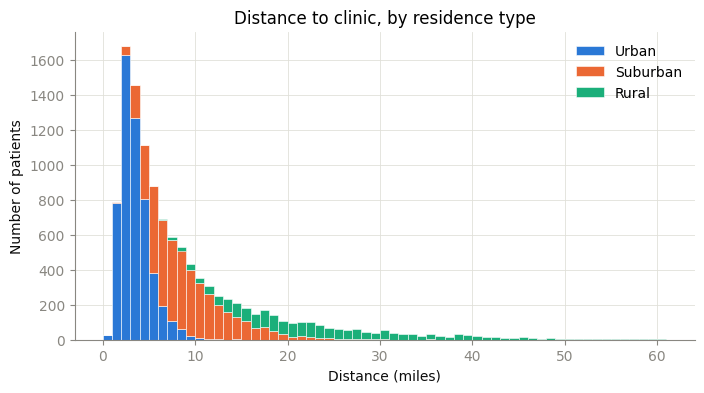

                count  median  mean
residence_type                     
Urban            5308     3.1   3.4
Suburban         4317     8.3   9.1
Rural            1898    22.1  24.9


In [21]:
groups = ["Urban", "Suburban", "Rural"]
colors = {"Urban": BLUE, "Suburban": ORANGE, "Rural": AQUA}
fig, ax = plt.subplots()
ax.hist([patients.loc[patients.residence_type == g, "distance_miles"] for g in groups], bins=np.arange(0, 62, 1),
        stacked=True, color=[colors[g] for g in groups], edgecolor="white", linewidth=0.4, label=groups)
ax.set_xlabel("Distance (miles)"); ax.set_ylabel("Number of patients"); ax.set_title("Distance to clinic, by residence type")
ax.legend(frameon=False); plt.show()

print(patients.groupby("residence_type")["distance_miles"].agg(["count", "median", "mean"]).loc[groups].round(1))

The bars are stacked, so the total height is the overall histogram from before, now coloured by group. Each group on its own is a neat right-skewed distribution (each is in fact log-normal), but with very different centres: urban patients live about 3 miles away, suburban about 8, rural about 22. The thick, flat tail of the overall histogram is almost entirely the rural patients.

This is a **mixture**: one variable, several underlying populations. The lesson is that a distribution that "doesn't look like anything" is often several clean distributions stacked on top of each other, and the way to find out is to split by a grouping variable you already have. Summarising a mixture with a single mean (9.1 miles) describes almost nobody.

## 6. Summary

| Variable | Unit of analysis | Centre | Spread | Shape | A distribution that describes it |
|---|---|---|---|---|---|
| Age | patient | mean ≈ median ≈ 52 | sd ≈ 17 | symmetric | normal |
| Lead time | appointment | median 11, mean 15.7 | P90 ≈ 33 | right-skewed | log-normal |
| Distance | patient | median 5.7, mean 9.1 | P90 ≈ 22 | right-skewed, lumpy | mixture of three log-normals (by residence type) |

Three habits to take away:

1. **Always draw the histogram first.** The numbers alone would not have revealed the second bump in distance.
2. **Match the summary to the shape.** Mean and standard deviation for symmetric variables; median and percentiles for skewed ones.
3. **When the shape is odd, look for a hidden grouping variable.**